# Init Google Colab

To be run only in Google Colab environment

In [1]:
try:
  import google.colab
  IN_COLAB = True
except:
  IN_COLAB = False

## Install necessary libraries

In [2]:
# Install necessary libraries

if IN_COLAB:
    !pip install python-dotenv==1.0.1
    !pip install openai==1.56.2
    !pip install requests==2.32.3
    !pip install httpx==0.28.1
    !pip install gdown
    !pip install faiss-cpu==1.9.0
    !pip install tiktoken==0.8.0

## Download utils from git repo

In [3]:
if IN_COLAB:
    user = "AndreyProfDev"
    repo = "articles_materials"

    # remove local directory if it already exists
    if os.path.isdir(repo):
        !rm -rf {repo}

    !git clone https://github.com/{user}/{repo}.git
    !rm -rf "{repo}/src/OpenAI or Open-Source? Choosing the Right Embedding Model for Polish Text.ipynb"

    import sys

    src_dir = "src"

    path = f"{repo}/{src_dir}"
    if not path in sys.path:
        sys.path.insert(1, path)

## Download data and cache

If you want to generate results from scratch then don't donwnload cache folder or just remove it

In [4]:

import tarfile
import os

if IN_COLAB:
    import gdown
    
    folders_to_download = [('https://drive.google.com/uc?id=1WairnDfu6HpYuTHxwUs1rdunL498UYqD', 'cache'),
                        ('https://drive.google.com/uc?id=14eXyre-s26vNXsh-cuzq9PvH9ZexuEIB', 'data')]

    for link, folder in folders_to_download:
        cache_folder = f'articles_materials/{folder}'

        if os.path.isdir(cache_folder):
            !rm -rf {cache_folder}

        file_path = f'articles_materials/{folder}.tar.gz'

        # Download the file
        gdown.download(link, file_path, quiet=False)

        # Path to the .tar.gz file

        # Open the tar.gz file
        with tarfile.open(file_path, 'r:gz') as tar:
            # Extract all the contents to a directory
            tar.extractall(path='articles_materials')

# Init Notebook

- Define necessary imports
- Initialise logging
- Initialize environment variables

In [9]:
from dotenv import load_dotenv
from openai import OpenAI
import os
from sentence_transformers import SentenceTransformer
from tqdm.autonotebook import tqdm
import matplotlib
import matplotlib.pyplot as plt
import logging
from tqdm.autonotebook import tqdm
import pandas as pd

# Load environment variables from .env file
load_dotenv()

# Set up logging
logging.basicConfig(level=logging.INFO)
logging.getLogger().setLevel(logging.INFO)

logging.info("Logging initiated")

# Set up OpenAI API
open_ai_key = os.environ["OPEN_AI_KEY"]

# Define paths
data_path = "embeddings_comparison/data"
cache_path = "embeddings_comparison/cache"

INFO:root:Logging initiated


# Display architecture of selected open source models

In [6]:
import embedding_models.providers.supported_models as supported_models

logging.getLogger("sentence_transformers.SentenceTransformer").setLevel(logging.WARNING)

# embedding_model = SentenceTransformer(supported_models.ST_POLISH_PARAPHRASE_FROM_MPNET.model_name)
# embedding_model = SentenceTransformer(supported_models.ORB_ST_POLISH_KARTONBERTA_BASE_ALPHA_V1.model_name)
# embedding_model = SentenceTransformer(supported_models.ORB_KARTONBERT_USE.model_name)

embedding_model = SentenceTransformer(supported_models.ST_POLISH_PARAPHRASE_FROM_DISTILROBERTA.model_name)
num_params = sum(p.numel() for p in embedding_model.parameters())

embedding_model.bfloat16()

print("Number of parameters: ", num_params, "\n")

print("Model architecture:\n" + str(embedding_model))

# Move to CPU to free up GPU memory
embedding_model.to("cpu");

Number of parameters:  124442880 

Model architecture:
SentenceTransformer(
  (0): Transformer({'max_seq_length': 256, 'do_lower_case': False}) with Transformer model: RobertaModel 
  (1): Pooling({'word_embedding_dimension': 768, 'pooling_mode_cls_token': False, 'pooling_mode_mean_tokens': True, 'pooling_mode_max_tokens': False, 'pooling_mode_mean_sqrt_len_tokens': False, 'pooling_mode_weightedmean_tokens': False, 'pooling_mode_lasttoken': False, 'include_prompt': True})
)


# Initialize Open AI client

Open AI client will be used to augment wiki data with generated question

In [7]:
from pathlib import Path
from llm_clients.cached_client import CachedLLMClient
from llm_clients.cost_monitoring import LLMClientWithCostMonitoring
from llm_clients.providers.open_ai_client import OpenAIClient
from llm_clients.providers import supported_models

openai_client = OpenAIClient(api_key=open_ai_key, model_info=supported_models.GPT_4O)
openai_client = CachedLLMClient(client=openai_client, path_to_cache = Path(f"{cache_path}/completion_cache"))
openai_client = LLMClientWithCostMonitoring(client=openai_client)

# Data curation

Process mediawiki xml files downloaded from wikipedia:
1) Extract text from xml
2) Clean text
3) Split text by sections

All intermediate data will be stored in the following subfolders:
- _0_raw files_ - contains original xml files
- _1_extracted_pages_ - contains yaml files with extracted text
- _2_processed_html_pages_ - contains yaml files with text after removing html tags
- _3_processed_markdown_pages_ - contains yaml files with text after removing markdown tags
- _4_split_sections_ - contains yaml files with text split by sections
- _5_remove_empty_articles_ - contains yaml files after removing empty articles

In [10]:
from pathlib import Path
import wiki_parser as wiki_parser
from pprint import pprint
from storage import ArticleStorage
import os

storage = ArticleStorage()

data_files = os.listdir(f"{data_path}/0_raw files")
pbar = tqdm(total = len(data_files))
for filename in data_files:
    pbar.set_description(f'Processing {filename}')
    if filename.endswith(".xml"):
        raw_pages = wiki_parser.extract_articles_from_file(f"{data_path}/0_raw files/" + filename, output_folder=Path(data_path))
        storage.save_articles(raw_pages)
    pbar.update(1)

pages_df = storage.load_all()

  0%|          | 0/18 [00:00<?, ?it/s]

# Data filtering

1) Load data from vector storage as pandas dataframe
2) Remove sections that don't contain text or sections with text just listing references
3) Build _Section With Context_ column by adding article title and section title to the section text

In [5]:
pages_df = storage.load_all()

pages_df = pages_df[pages_df['Section Title'] != 'Linki zewnętrzne']
pages_df = pages_df[pages_df['Section Title'] != 'Zobacz też']
pages_df = pages_df[pages_df['Section Title'] != 'Bibliografia']
pages_df = pages_df[pages_df['Section Title'] != 'Przypisy']

pages_df['Section With Context'] = pages_df['Article Title'] + '\n' + pages_df['Section Title'] + '\n' + pages_df['Section Content']
pages_df.loc[pages_df['Section Title'] == 'Main', 'Section With Context'] = pages_df['Article Title'] + '\n' + pages_df['Section Content']

pages_df = pages_df.drop_duplicates()
pages_df = pages_df.reset_index(drop=True)

pages_df.head()

,Article Title,Section Title,Section Content,Section With Context
0,Protohistoria,Main,Protohistoria – termin określający dzieje społ...,Protohistoria\nProtohistoria – termin określaj...
1,Polityka historyczna,Main,Polityka historyczna () lub polityka pamięci –...,Polityka historyczna\nPolityka historyczna () ...
2,Polityka historyczna,Geneza pojęcia,Polityka historyczna wynika z potrzeby mitolog...,Polityka historyczna\nGeneza pojęcia\nPolityka...
3,Polityka historyczna,Narzędzia polityki historycznej,Narzędziami polityki historycznej są finansowa...,Polityka historyczna\nNarzędzia polityki histo...
4,Polityka historyczna,Zagadnienie polityki historycznej w Polsce,"Także po okresie PRL, kiedy to wdrażano stosow...",Polityka historyczna\nZagadnienie polityki his...


# Data Augmentation

Generate artificial questions for each section using Open AI client

In [6]:
from question_generation import BASE_PROMT_PL, generate_question_for_text
from tqdm.auto import tqdm
from time import sleep

logging.getLogger("httpx").setLevel(logging.WARNING)

pbar = tqdm(total=len(pages_df))
questions_column = []

promt_tokens_bar = tqdm(desc="Promt cost ($): ")
completions_tokens_bar = tqdm(desc="Completions cost ($):")

for _, row in pages_df.iterrows():
    pbar.set_description(f"Generating questions for {row['Article Title']}/{row['Section Title']}")
    
    questions = generate_question_for_text(openai_client, row['Section With Context'], BASE_PROMT_PL)
    questions_column.append(questions.questions)

    pbar.update(1)
    promt_tokens_bar.update(openai_client.get_total_promt_cost() - promt_tokens_bar.n)
    completions_tokens_bar.update(openai_client.get_total_completion_cost() - completions_tokens_bar.n)

pages_df['questions'] = questions_column

  0%|          | 0/1653 [00:00<?, ?it/s]

Promt cost ($): : 0it [00:00, ?it/s]

Completions cost ($):: 0it [00:00, ?it/s]

# Data Ingestion

## Ingestion of data into the database

In [7]:
from utils.embedding_models.providers import hugging_face
from utils.embedding_models.providers import open_ai
from utils.embedding_models.providers import supported_models
from utils.vectordb.vectordb import VectorDB

logging.getLogger("httpx").setLevel(logging.WARNING)

path_to_cache = Path(f"{cache_path}/embeddings_cache")

# Define embedding models
embedding_models = {
    "HF_SDADAS": hugging_face.init_model(model_info=supported_models.ST_POLISH_PARAPHRASE_FROM_DISTILROBERTA, path_to_cache=path_to_cache),
    "OPENAI_SMALL": open_ai.init_model(api_key=open_ai_key, model_info=supported_models.TEXT_EMBEDDING_3_SMALL, path_to_cache=path_to_cache),
    "OPENAI_LARGE": open_ai.init_model(api_key=open_ai_key, model_info=supported_models.TEXT_EMBEDDING_3_LARGE, path_to_cache=path_to_cache),
    "OPENAI__ADA": open_ai.init_model(api_key=open_ai_key, model_info=supported_models.TEXT_EMBEDDING_ADA_002, path_to_cache=path_to_cache),
    "HF_MPNET": hugging_face.init_model(model_info=supported_models.ST_POLISH_PARAPHRASE_FROM_MPNET, path_to_cache=path_to_cache),
    "HF_KARTONBERTA": hugging_face.init_model(model_info=supported_models.ORB_ST_POLISH_KARTONBERTA_BASE_ALPHA_V1, path_to_cache=path_to_cache),
    "ORB_KARTONBERT_USE": hugging_face.init_model(model_info=supported_models.ORB_KARTONBERT_USE),

}

# Initialize vector database and add indices (one per each embedding model)
vector_db = VectorDB()
for index_name, index in embedding_models.items():
    vector_db.add_index(index_name, index)

# Populate each index with data
sections = pages_df['Section With Context'].values.tolist()
for index_name in vector_db.list_indices():
    cost_bar = tqdm(desc=f'{index_name}. Total cost ($)')
    model = embedding_models[index_name]
    for text in tqdm(sections, desc=f'{index_name}. Processed items'):
        vector_db.insert_text(text, index_name)
        cost_bar.update(model.get_total_cost() - cost_bar.n)

INFO:faiss.loader:Loading faiss with AVX2 support.
INFO:faiss.loader:Successfully loaded faiss with AVX2 support.


HF_SDADAS. Total cost ($): 0it [00:00, ?it/s]

HF_SDADAS. Processed items:   0%|          | 0/1653 [00:00<?, ?it/s]

OPENAI_SMALL. Total cost ($): 0it [00:00, ?it/s]

OPENAI_SMALL. Processed items:   0%|          | 0/1653 [00:00<?, ?it/s]

...

HF_MPNET. Processed items:   0%|          | 0/1653 [00:00<?, ?it/s]

HF_KARTONBERTA. Total cost ($): 0it [00:00, ?it/s]

HF_KARTONBERTA. Processed items:   0%|          | 0/1653 [00:00<?, ?it/s]

ORB_KARTONBERT_USE. Total cost ($): 0it [00:00, ?it/s]

ORB_KARTONBERT_USE. Processed items:   0%|          | 0/1653 [00:00<?, ?it/s]

## Ingestion cost

,Cost ($)
Model,
text-embedding-3-large,0.096215
text-embedding-ada-002,0.074012
text-embedding-3-small,0.014802


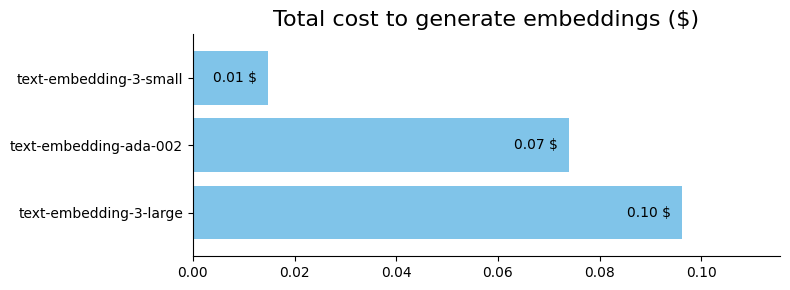

In [8]:
from chart_utils import draw_bar_chart

embeddings_costs = [{"Model" : model.model_info.model_name, "Cost ($)": model.get_total_cost()} for model in embedding_models.values()]
embeddings_costs_df = pd.DataFrame(embeddings_costs)
embeddings_costs_df = embeddings_costs_df.sort_values("Cost ($)", ascending=False)
embeddings_costs_df = embeddings_costs_df.set_index("Model")
embeddings_costs_df = embeddings_costs_df[embeddings_costs_df["Cost ($)"] > 0]

display(embeddings_costs_df)

draw_bar_chart(df=embeddings_costs_df, title='Total cost to generate embeddings ($)', bar_label_format = "%.2f $", 
               grey_colors=['#80C4E9'], highlight_colors=['#80C4E9'], numeric_labels_padding = -40, size=(8, 3))

## Ingestion time

,Total time
Model,
text-embedding-3-large,889.772753
text-embedding-3-small,597.100254
text-embedding-ada-002,545.270324
sdadas/st-polish-paraphrase-from-mpnet,12.277242
OrlikB/st-polish-kartonberta-base-alpha-v1,11.360559
OrlikB/KartonBERT-USE-base-v1,11.096302
sdadas/st-polish-paraphrase-from-distilroberta,10.419555


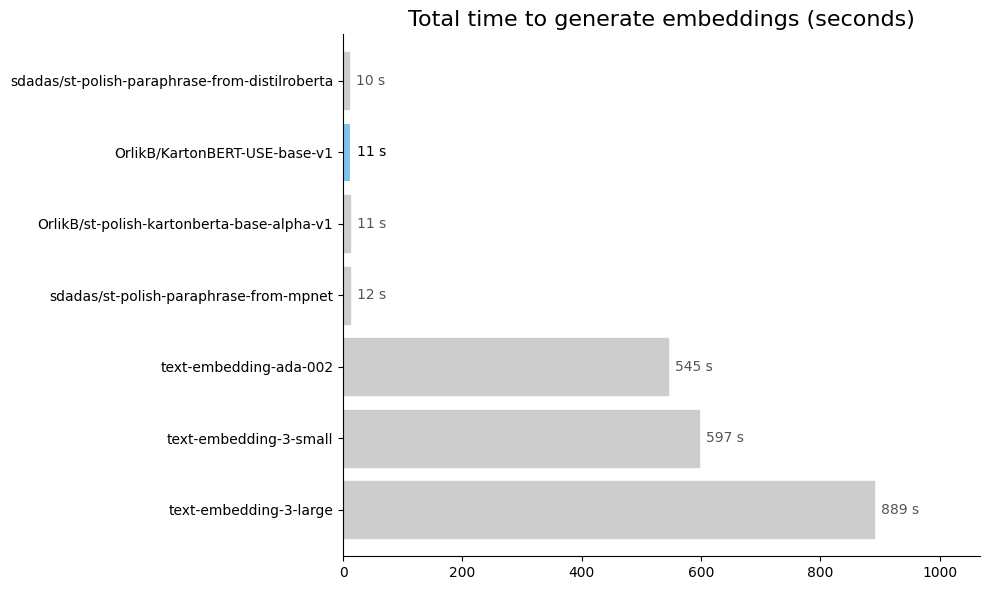

In [9]:
from utils.embedding_models.providers.supported_models import ORB_KARTONBERT_USE
from chart_utils import draw_bar_chart

embeddings_time = [{"Model" : model.model_info.model_name, "Total time": model.get_total_time()} for model in embedding_models.values()]
embeddings_time_df = pd.DataFrame(embeddings_time)
embeddings_time_df = embeddings_time_df.sort_values(by="Total time", ascending=False)
embeddings_time_df = embeddings_time_df.set_index("Model")
display(embeddings_time_df)

draw_bar_chart(df=embeddings_time_df, title='Total time to generate embeddings (seconds)', 
               bar_label_format = "%d s", grey_colors=['#CDCDCD'], highlight_colors=['#80C4E9'], numeric_labels_padding=5, 
               to_highlight=[ORB_KARTONBERT_USE.model_name])

# Model Evaluation

## Running the evaluation

In [10]:
from tqdm.autonotebook import tqdm

test_df = pages_df.copy() #[:800]

evaluatiion_results = []

for index_name in vector_db.list_indices():
    model = embedding_models[index_name]
    cost = model.get_total_cost()
    embedding_tokens_bar = tqdm(desc=f"{index_name}. Embedding cost ($): ")

    for k in [1, 5, 10]:
        for _, row in tqdm(list(test_df.iterrows()), desc=f"{index_name}. k={k}. Wiki sections: "):
            matched_with_answer = 0
            for question in row['questions']:

                found_text = vector_db.find_text(text=question, top_k=k, index_name=index_name)
                
                embedding_tokens_bar.update(model.get_total_cost() - cost - embedding_tokens_bar.n)
                evaluatiion_results.append({
                    "Model Name": model.model_info.model_name,
                    "k": k,
                    "Section": row['Section With Context'],
                    "Question": question,
                    "Found text": found_text,
                    "Matched with answer": row['Section With Context'] in found_text
                })

evaluatiion_results_df = pd.DataFrame(evaluatiion_results)
evaluatiion_results_df = evaluatiion_results_df.pivot_table(index=['Section', 'Question', 'Model Name'], columns=['k'], values=['Matched with answer'], aggfunc='sum').add_prefix('k=')
evaluatiion_results_df = evaluatiion_results_df.droplevel(0, axis=1).reset_index()
evaluatiion_results_df.head()

HF_SDADAS. Embedding cost ($): : 0it [00:00, ?it/s]

HF_SDADAS. k=1. Wiki sections:   0%|          | 0/1653 [00:00<?, ?it/s]

HF_SDADAS. k=5. Wiki sections:   0%|          | 0/1653 [00:00<?, ?it/s]

HF_SDADAS. k=10. Wiki sections:   0%|          | 0/1653 [00:00<?, ?it/s]

OPENAI_SMALL. Embedding cost ($): : 0it [00:00, ?it/s]

...

ORB_KARTONBERT_USE. Embedding cost ($): : 0it [00:00, ?it/s]

ORB_KARTONBERT_USE. k=1. Wiki sections:   0%|          | 0/1653 [00:00<?, ?it/s]

ORB_KARTONBERT_USE. k=5. Wiki sections:   0%|          | 0/1653 [00:00<?, ?it/s]

ORB_KARTONBERT_USE. k=10. Wiki sections:   0%|          | 0/1653 [00:00<?, ?it/s]

k,Section,Question,Model Name,k=1,k=5,k=10
0,"ASInfo\nASInfo – pierwsza w Polsce, sportowa a...",Jakie rodzaje treści dostarcza agencja ASInfo?,OrlikB/KartonBERT-USE-base-v1,1,1,1
1,"ASInfo\nASInfo – pierwsza w Polsce, sportowa a...",Jakie rodzaje treści dostarcza agencja ASInfo?,OrlikB/st-polish-kartonberta-base-alpha-v1,1,1,1
2,"ASInfo\nASInfo – pierwsza w Polsce, sportowa a...",Jakie rodzaje treści dostarcza agencja ASInfo?,sdadas/st-polish-paraphrase-from-distilroberta,1,1,1
3,"ASInfo\nASInfo – pierwsza w Polsce, sportowa a...",Jakie rodzaje treści dostarcza agencja ASInfo?,sdadas/st-polish-paraphrase-from-mpnet,1,1,1
4,"ASInfo\nASInfo – pierwsza w Polsce, sportowa a...",Jakie rodzaje treści dostarcza agencja ASInfo?,text-embedding-3-large,1,1,1


## Average number of questions correctly answered

Mean number of questions matched with answer


k,k=1,k=5,k=10
Model Name,,,
sdadas/st-polish-paraphrase-from-distilroberta,3.127647,4.307320,4.567453
sdadas/st-polish-paraphrase-from-mpnet,3.142166,4.303690,4.560194
text-embedding-ada-002,3.500907,4.552329,4.752571
OrlikB/st-polish-kartonberta-base-alpha-v1,3.617060,4.661222,4.818512
text-embedding-3-small,3.647308,4.646098,4.817302


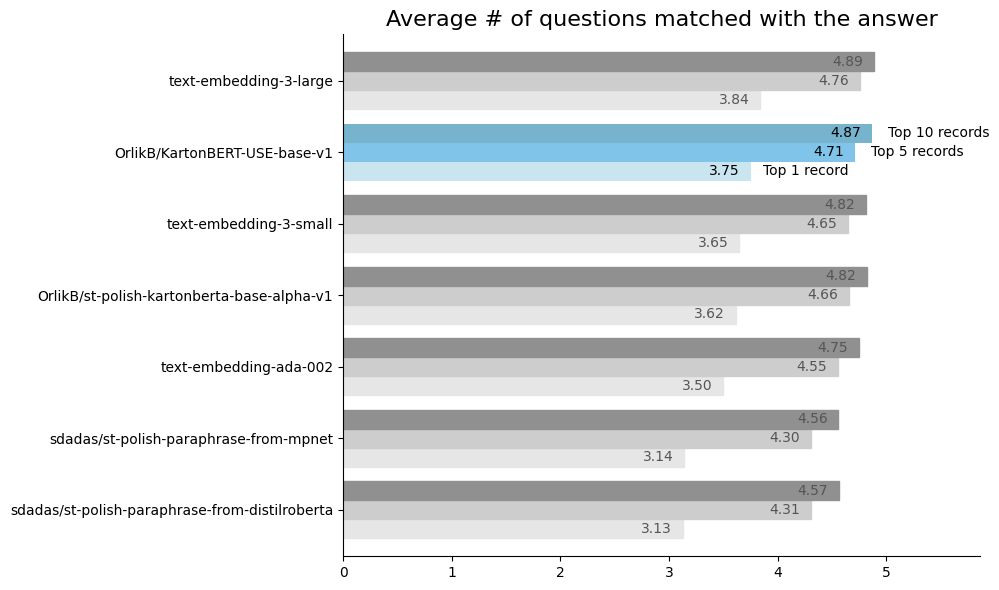

In [11]:
questions_per_section_df = evaluatiion_results_df.groupby(['Section', 'Model Name'])[['k=1', 'k=5', 'k=10']].sum()
meand_qs_df = questions_per_section_df.groupby('Model Name').mean().reset_index()
meand_qs_df.set_index('Model Name', inplace=True)
meand_qs_df = meand_qs_df.sort_values(by='k=1', ascending=True)

print('Mean number of questions matched with answer')
display(meand_qs_df.head())

meand_qs_df.columns = ['Top 1 record', 'Top 5 records', 'Top 10 records']
draw_bar_chart(meand_qs_df, title="Average # of questions matched with the answer", to_highlight=[ORB_KARTONBERT_USE.model_name])

## Total number of questions correctly answered

k,k=1,k=5,k=10
Model Name,,,
sdadas/st-polish-paraphrase-from-distilroberta,5170,7120,7550
sdadas/st-polish-paraphrase-from-mpnet,5194,7114,7538
text-embedding-ada-002,5787,7525,7856
OrlikB/st-polish-kartonberta-base-alpha-v1,5979,7705,7965
text-embedding-3-small,6029,7680,7963
OrlikB/KartonBERT-USE-base-v1,6204,7793,8047
text-embedding-3-large,6346,7866,8076


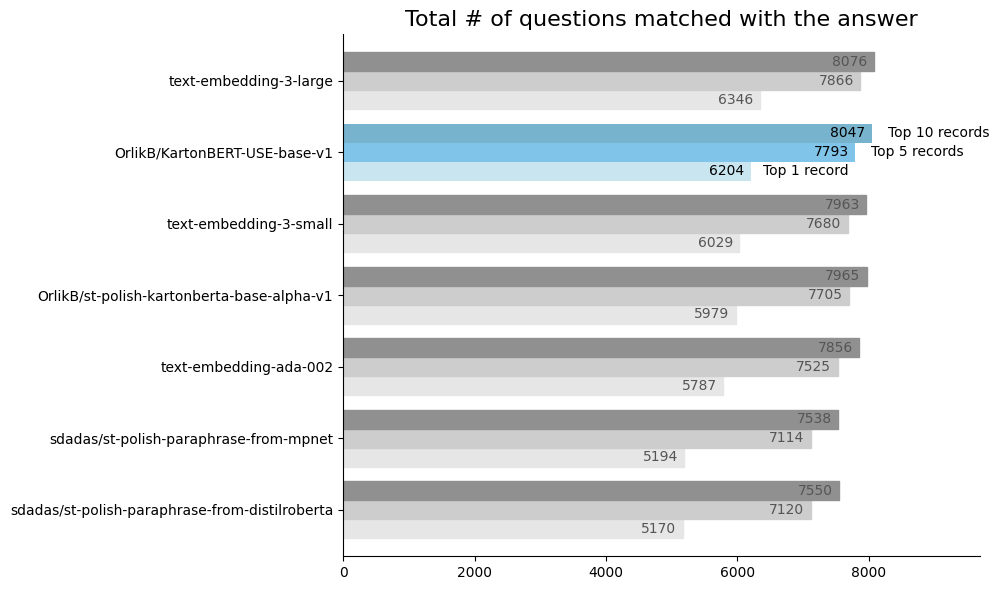

In [12]:
total_qs_df = evaluatiion_results_df.groupby(['Model Name'])[['k=1', 'k=5', 'k=10']].sum()
total_qs_df = total_qs_df.sort_values(by='k=1', ascending=True)

display(total_qs_df)

total_qs_df.columns = ['Top 1 record', 'Top 5 records', 'Top 10 records']
draw_bar_chart(total_qs_df, title="Total # of questions matched with the answer", 
               bar_label_format="%d", 
               to_highlight=[ORB_KARTONBERT_USE.model_name])